In [1]:
# Import libraries

# First, let’s import all of the modules, functions and objects we are going to use in this tutorial.

# Load libraries
import pandas
import numpy
from pandas.tools.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC

# Load Dataset

readdata = pandas.read_csv('BDParkinson_Prediction.csv')
dataset = pandas.DataFrame(readdata, columns=['VAR1', 'VAR2', 'VAR3', 'VAR4', 'VAR5', 'VAR6', 'CLASS'])

# Summarize the Dataset

# shape
print(dataset.shape)

# head
print(dataset.head(20))

# Statistical Summary

# descriptions
print(dataset.describe())

# Class Distribution

# class distribution
print(dataset.groupby('CLASS').size())

# Evaluate Some Algorithms

# Now it is time to create some models of the data and estimate their accuracy on unseen data.

# Here is what we are going to cover in this step:

# Separate out a validation dataset.
# Set-up the test harness to use 10-fold cross validation.
# Select the best model.

# Split-out validation dataset
array = dataset.values
X = array[:,0:6]
Y = array[:,6]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(X, Y, test_size=validation_size, random_state=seed)

# You now have training data in the X_train and Y_train for preparing models and a X_validation and Y_validation sets that we can use later.

# We will use 10-fold cross validation to estimate accuracy.

# This will split our dataset into 10 parts, train on 9 and test on 1 and repeat for all combinations of train-test splits.

# Test options and evaluation metric

# When you use random_state=some_number, then you can guarantee that the output of Run 1 will be equal to the output of Run 2, i.e. your split will be always the same. It doesn't matter what the actual random_state number is 42, 0, 21, ... The important thing is that everytime you use 42, you will always get the same output the first time you make the split. This is useful if you want reproducible results

seed = 7
scoring = 'accuracy'

# We are using the metric of ‘accuracy‘ to evaluate models. This is a ratio of the number of correctly predicted instances in divided by the total number of instances in the dataset multiplied by 100 to give a percentage (e.g. 95% accurate). We will be using the scoring variable when we run build and evaluate each model next.

# Build Models

# We don’t know which algorithms would be good on this problem or what configurations to use. We get an idea from the plots that some of the classes are partially linearly separable in some dimensions, so we are expecting generally good results.

# Let’s evaluate 4 different algorithms:

# Logistic Regression (LR)
# Linear Discriminant Analysis (LDA)
# K-Nearest Neighbors (KNN).
#Support Vector Machines (SVM).

# This is a good mixture of simple linear (LR and LDA), nonlinear (KNN, NB and SVM) algorithms.


# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC()))
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, random_state=seed)
    cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# We can also create a plot of the model evaluation results and compare the spread and the mean accuracy of each model. There is a population of accuracy measures for each algorithm because each algorithm was evaluated 10 times (10 fold cross validation).

# Compare Algorithms Accuracy
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

(500, 7)
        VAR1      VAR2  VAR3      VAR4      VAR5      VAR6    CLASS
0   0.624731  0.135424   0.0  0.675282  0.182203  0.962960  Class_1
1   0.647223  0.136211   0.0  0.679511  0.195903  0.987387  Class_1
2   0.706352  0.187593   0.0  0.632989  0.244884  0.991182  Class_1
3   0.680291  0.192076   0.0  0.651786  0.233528  0.991857  Class_1
4   0.660104  0.161131   0.0  0.677162  0.209531  0.991066  Class_1
5   0.613417  0.139781   0.0  0.694079  0.195339  0.990384  Class_1
6   0.616898  0.140754   0.0  0.723214  0.209619  0.990327  Class_1
7   0.656328  0.154513   0.0  0.710056  0.233812  0.990833  Class_1
8   0.669818  0.149971   0.0  0.701598  0.218213  0.990577  Class_1
9   0.613236  0.110929   0.0  0.734492  0.165860  0.989756  Class_1
10  0.631720  0.117446   0.0  0.716635  0.181714  0.990120  Class_1
11  0.689303  0.125571   0.0  0.705827  0.217929  0.989755  Class_1
12  0.690087  0.129420   0.0  0.690319  0.225446  0.990173  Class_1
13  0.678321  0.120775   0.0  0.717105 

/anaconda2/lib/python2.7/site-packages/sklearn/discriminant_analysis.py:442: UserWarning: The priors do not sum to 1. Renormalizing
  UserWarning)


<Figure size 640x480 with 1 Axes>

In [2]:
KNN = KNeighborsClassifier()
KNN.fit(X_train, Y_train) #This builds the algo around training sets 
predictions = KNN.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

1.0
[[26  0  0  0]
 [ 0 22  0  0]
 [ 0  0 22  0]
 [ 0  0  0 30]]
             precision    recall  f1-score   support

     Class2       1.00      1.00      1.00        26
    Class_1       1.00      1.00      1.00        22
    Class_3       1.00      1.00      1.00        22
    Class_4       1.00      1.00      1.00        30

avg / total       1.00      1.00      1.00       100



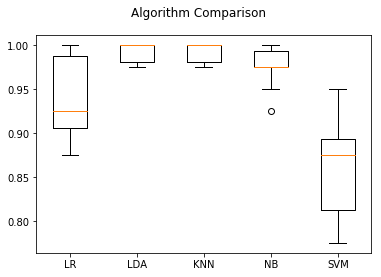

In [3]:
# Compare Algorithms Accuracy
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [3]:
predictions

array(['Class_3', 'Class_1', 'Class_4', 'Class_1', 'Class_4', 'Class2',
       'Class2', 'Class2', 'Class2', 'Class_3', 'Class2', 'Class_4',
       'Class_4', 'Class2', 'Class_4', 'Class_4', 'Class_4', 'Class_4',
       'Class_4', 'Class_3', 'Class2', 'Class2', 'Class_3', 'Class_1',
       'Class2', 'Class_4', 'Class_1', 'Class_1', 'Class_1', 'Class_3',
       'Class_4', 'Class_3', 'Class_1', 'Class_3', 'Class2', 'Class_4',
       'Class_4', 'Class2', 'Class_4', 'Class2', 'Class2', 'Class_3',
       'Class_1', 'Class_3', 'Class_3', 'Class_1', 'Class_3', 'Class2',
       'Class_4', 'Class_4', 'Class_4', 'Class_4', 'Class_4', 'Class_3',
       'Class_4', 'Class_4', 'Class2', 'Class_3', 'Class2', 'Class2',
       'Class_4', 'Class2', 'Class_3', 'Class_4', 'Class_1', 'Class_3',
       'Class_4', 'Class_3', 'Class_3', 'Class_4', 'Class_3', 'Class_1',
       'Class_1', 'Class_3', 'Class_1', 'Class_4', 'Class_1', 'Class_4',
       'Class2', 'Class_3', 'Class_1', 'Class_1', 'Class_3', 'Class_1

In [4]:
Y_validation

array(['Class_3', 'Class_1', 'Class_4', 'Class_1', 'Class_4', 'Class2',
       'Class2', 'Class2', 'Class2', 'Class_3', 'Class2', 'Class_4',
       'Class_4', 'Class2', 'Class_4', 'Class_4', 'Class_4', 'Class_4',
       'Class_4', 'Class_3', 'Class2', 'Class2', 'Class_3', 'Class_1',
       'Class2', 'Class_4', 'Class_1', 'Class_1', 'Class_1', 'Class_3',
       'Class_4', 'Class_3', 'Class_1', 'Class_3', 'Class2', 'Class_4',
       'Class_4', 'Class2', 'Class_4', 'Class2', 'Class2', 'Class_3',
       'Class_1', 'Class_3', 'Class_3', 'Class_1', 'Class_3', 'Class2',
       'Class_4', 'Class_4', 'Class_4', 'Class_4', 'Class_4', 'Class_3',
       'Class_4', 'Class_4', 'Class2', 'Class_3', 'Class2', 'Class2',
       'Class_4', 'Class2', 'Class_3', 'Class_4', 'Class_1', 'Class_3',
       'Class_4', 'Class_3', 'Class_3', 'Class_4', 'Class_3', 'Class_1',
       'Class_1', 'Class_3', 'Class_1', 'Class_4', 'Class_1', 'Class_4',
       'Class2', 'Class_3', 'Class_1', 'Class_1', 'Class_3', 'Class_1

In [5]:
print(accuracy_score(Y_validation, predictions))

1.0
